In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
from scipy import linalg as la
from matplotlib import pyplot as plt
import matplotlib

import adaptive

from tai_localiser.lauralizer import amorphous_model_BHZ_2D as am
from tai_localiser.lauralizer.amorphous_model_BHZ_2D import amorph_BHZ, zero_params
from tai_localiser.lauralizer.localizer import (
    spectral_localizer_AII2D,
    pfaff_sign,
    local_gap_localizer,
)
from tai_localiser.perulizer import proximity_lattice, proximity_bonds

from koala.lattice import Lattice
from koala import pointsets
from koala import plotting as pl
import kwant as k

# local imports
from func_for_fig4 import param_obs_2b

adaptive.notebook_extension()

ImportError: cannot import name 'zero_params' from 'tai_localizer.lauralizer.amorphous_model_BHZ_2D' (/Users/perudornellas/physics_projects/TAI-localizer/src/tai_localizer/lauralizer/amorphous_model_BHZ_2D.py)

In [ ]:
matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [ ]:
# lattice parameters
system_size = 10
bond_distance = 1.3 / system_size
beta = 1
sigma_bounds = (0.0, 0.1 / system_size)
kappa_shift = 0.5


# model parameters
A = 1.0
B = 1.0
delta = 2.0
delta_bounds = (-2, 4)
alpha = 0.0
onsite_disorder = 0
disorder_bounds = (0, 15)
hadamard_disorder = 0.15
bond_power = 1

# localiser parameter
kappa = 1

# run parameters
disorder_averages = 100
n_task = 8


def goal(l):
    # return l.loss() < 0.05  # continue until loss is small enough
    return l.npoints > 200  # continue until 1000 points


fname = "results/fig_2_b_2"

In [ ]:
# check it runs
x = param_obs_2b(
    system_size,
    sigma_bounds[-1],
    kappa_shift,
    bond_distance,
    A,
    B,
    delta,
    onsite_disorder=onsite_disorder,
    hadamard_disorder=0.9,
    kappa_spec=1,
    disorder_average=1,
    beta=beta,
    bond_power=bond_power,
)

# 2.a

In [ ]:
# setup the onsite disorder learner

f = lambda sig_delta: param_obs_2b(
    system_size,
    0,
    0,
    bond_distance,
    A,
    B,
    sig_delta[0],
    onsite_disorder=sig_delta[1],
    hadamard_disorder=hadamard_disorder,
    kappa_spec=kappa,
    disorder_average=disorder_averages,
    beta=beta,
    bond_power=bond_power,
)

learner_dis = adaptive.Learner2D(
    f,
    bounds=[
        delta_bounds,
        disorder_bounds,
    ],
)

# learner_dis.load(f"{fname}onsite.pkl")

runner_dis = adaptive.Runner(
    learner_dis,
    goal=goal,
    ntasks=n_task,
)

runner_dis.live_info()

In [ ]:
# # lets add a check of the graphs that we want to generate
# n_points = 10
# initial_points = pointsets.grid(system_size, system_size)

# fig, ax = plt.subplots(
#     n_points // 5,
#     5,
#     figsize=(aps_figwidth, (n_points // 5) * aps_figwidth / 5),
#     dpi=300,
# )

# sigmas = np.linspace(sigma_bounds[0], sigma_bounds[1] * 1, n_points)
# for a, sigma in zip(ax.flatten(), sigmas):

#     p = pointsets.move_all_points(initial_points, sigma, kappa_shift, beta)

#     a.set_xticks([])
#     a.set_yticks([])
#     a.set_aspect("equal")

#     a.scatter(*p.T, s=1, color="black")
#     lat = proximity_lattice(p, bond_distance)
#     pl.plot_edges(lat, ax=a, color="blue", linewidth=0.5, zorder=-1)

2b

In [ ]:
f = lambda sig_delta: param_obs_2b(
    system_size,
    sig_delta[1],
    0,
    bond_distance,
    A,
    B,
    sig_delta[0],
    onsite_disorder=onsite_disorder,
    hadamard_disorder=hadamard_disorder,
    kappa_spec=1,
    disorder_average=disorder_averages,
    beta=1,
    bond_power=bond_power,
)

learner_sig = adaptive.Learner2D(
    f,
    bounds=[
        delta_bounds,
        sigma_bounds,
    ],
)

# learner_sig.load(f"{fname}structural.pkl")

runner_sig = adaptive.Runner(
    learner_sig,
    goal=goal,
    ntasks=n_task,
)

runner_sig.live_info()

In [ ]:
f = lambda sig_delta: param_obs_2b(
    system_size,
    sig_delta[1],
    kappa_shift,
    bond_distance,
    A,
    B,
    sig_delta[0],
    onsite_disorder=onsite_disorder,
    hadamard_disorder=hadamard_disorder,
    kappa_spec=1,
    disorder_average=disorder_averages,
    beta=1,
    bond_power=bond_power,
)

learner_sig_kappa = adaptive.Learner2D(
    f,
    bounds=[
        delta_bounds,
        sigma_bounds,
    ],
)

# learner_sig_kappa.load(f"{fname}structural_{kappa_shift}.pkl")

runner_sig_kappa = adaptive.Runner(
    learner_sig_kappa,
    goal=goal,
    ntasks=n_task,
)

runner_sig_kappa.live_info()

In [ ]:
# learner_dis.save(f"{fname}onsite.pkl")
# learner_sig.save(f"{fname}structural.pkl")
# learner_sig_kappa.save(f"{fname}structural_{kappa_shift}.pkl")

# Make the plot

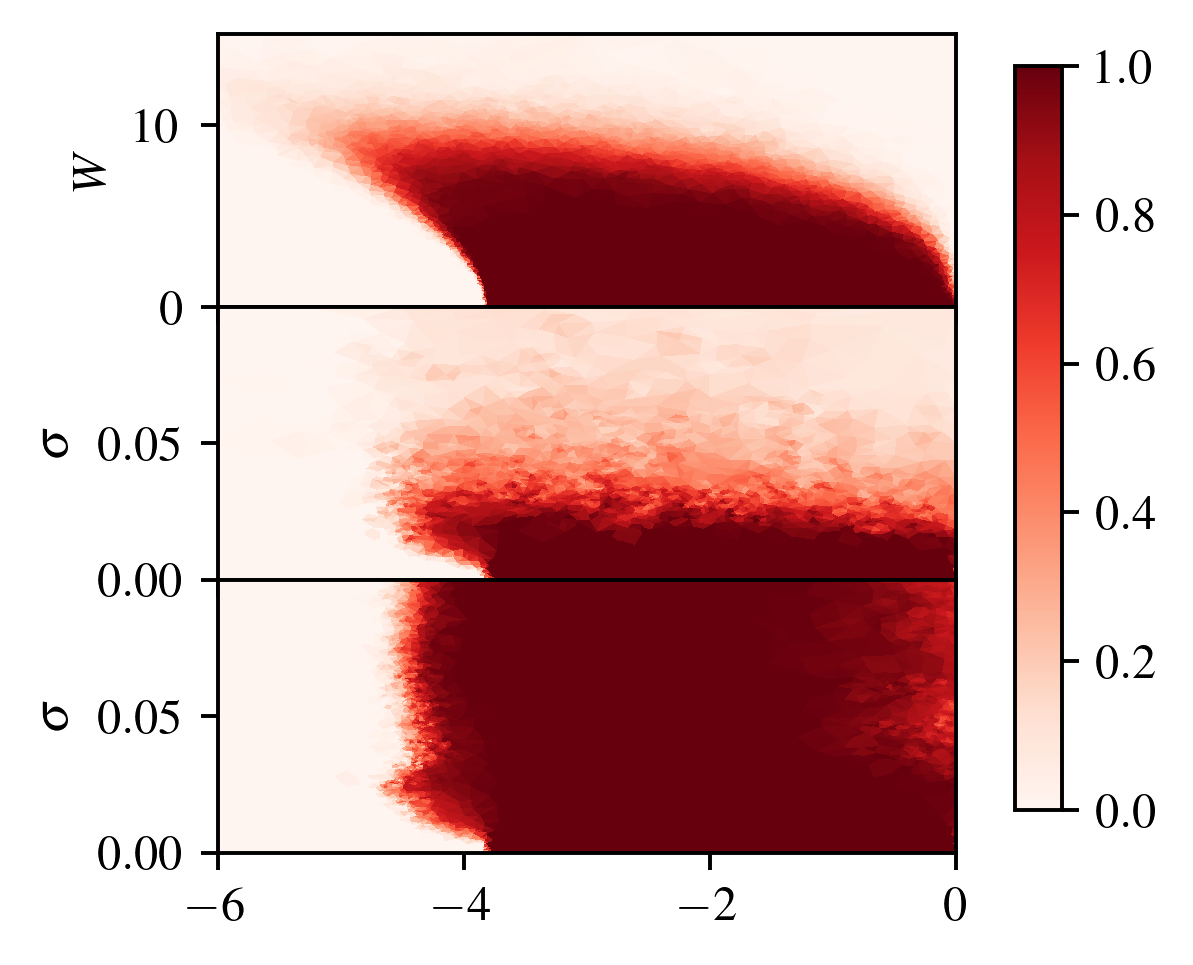

In [ ]:
fig, ax = plt.subplots(
    3, 1, figsize=(aps_halfwidth, 0.9 * aps_halfwidth), dpi=350, sharex=True
)
plt.subplots_adjust(hspace=0)
######### 2a #########

specs = np.array([learner_dis.data[k] for k in learner_dis.data.keys()])
positions = np.array([k for k in learner_dis.data.keys()])
specs = 0.5 * (1 - specs)


triangle = matplotlib.tri.Triangulation(
    positions[:, 0] / max(positions[:, 0]),
    positions[:, 1] / max(positions[:, 1]),
)


p1 = ax[0].tripcolor(
    positions[:, 0] - 4,
    positions[:, 1],
    triangle.triangles,
    specs,
    # shading="gouraud",
    cmap="Reds",
    clim=(0, 1),
)


######### 2b #########
specs = np.array([learner_sig.data[k] for k in learner_sig.data.keys()])
positions = np.array([k for k in learner_sig.data.keys()])
specs = 0.5 * (1 - specs)


triangle = matplotlib.tri.Triangulation(
    positions[:, 0] / max(positions[:, 0]),
    positions[:, 1] / max(positions[:, 1]),
)

p2 = ax[1].tripcolor(
    positions[:, 0] - 4,
    positions[:, 1] * system_size,
    triangle.triangles,
    specs,
    # shading="gouraud",
    cmap="Reds",
    clim=(0, 1),
)

######### 2c #########
specs = np.array([learner_sig_kappa.data[k] for k in learner_sig_kappa.data.keys()])
positions = np.array([k for k in learner_sig_kappa.data.keys()])
specs = 0.5 * (1 - specs)


triangle = matplotlib.tri.Triangulation(
    positions[:, 0] / max(positions[:, 0]),
    positions[:, 1] / max(positions[:, 1]),
)

p2 = ax[2].tripcolor(
    positions[:, 0] - 4,
    positions[:, 1] * system_size,
    triangle.triangles,
    specs,
    # shading="gouraud",
    cmap="Reds",
    clim=(0, 1),
)


ax[0].set_xlim(np.array(delta_bounds) - 4)
ax[0].set_ylim(disorder_bounds)

ax[1].set_xlim(np.array(delta_bounds) - 4)
ax[1].set_ylim(np.array(sigma_bounds) * system_size)

ax[2].set_xlim(np.array(delta_bounds) - 4)
ax[2].set_ylim(np.array(sigma_bounds) * system_size)


ax[1].set_yticks(
    [
        0,
        0.05,
    ]
)
ax[2].set_yticks(
    [
        0,
        0.05,
    ]
)

# ax[0].set_xlabel(r"$\Delta$")
ax[1].set_xlabel(r"$\Delta$")
ax[0].set_ylabel(r"$W$")
ax[1].set_ylabel(r"$\sigma$")
ax[2].set_ylabel(r"$\sigma$")


fig.subplots_adjust(right=0.75)
cbar_ax = fig.add_axes([0.8, 0.15, 0.04, 0.7])
fig.colorbar(p2, cax=cbar_ax)


# t = ax[0].text(0.03,.95,'a)',backgroundcolor='1',alpha=1)
# plt.colorbar(p1, ax=ax[0], aspect=16, shrink=0.9)
# plt.colorbar(p2, ax=ax[1], aspect=16, shrink=0.9)

# plt.tight_layout()

# mpl.rcParams['ytick.major.pad'] = 8


plt.savefig("fig_2.pdf", dpi=350, bbox_inches="tight")

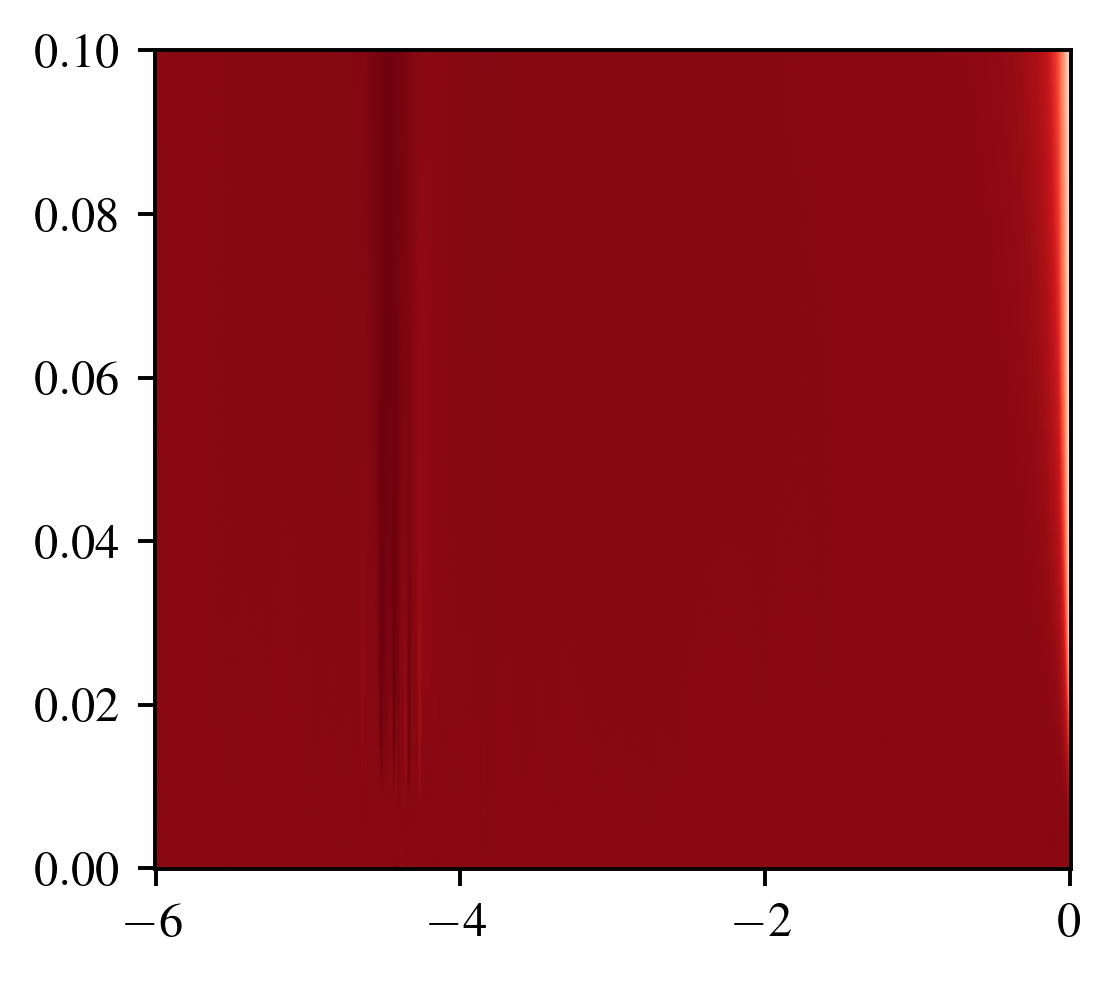

In [ ]:
from scipy.interpolate import Rbf

Xi, Yi = np.meshgrid(
    np.linspace(delta_bounds[0], delta_bounds[1], 100),
    np.linspace(sigma_bounds[0], sigma_bounds[1], 100) * system_size,
)

rbf = Rbf(*positions.T, specs, function="multiquadric")
Zi = rbf(Xi, Yi)

fig, ax = plt.subplots(figsize=(aps_halfwidth, 0.9 * aps_halfwidth), dpi=350)
ax.pcolormesh(Xi - 4, Yi, Zi, cmap="Reds")

In [ ]:
specs
# positions

array([0.  , 0.  , 0.96, ..., 0.49, 0.59, 0.78], shape=(1001,))